# Simulation and Test of Wavefront Sensing Method

__Author:__ Wei "Francis" He (francisho@lbl.gov, wehe@ucsd.edu)

__Version:__ Created in Oct 2025; Last edited in May 2026

___

## Overview 

__Description:__ 

This notebook includes the simulation of an updated wavefront reconstruction method using FFT-based lateral shearing interferometry, as well as a quick test for real data measured at COSMIC @ ALS in 2021. 

__References:__
- Code adapted from [Xiaoya and Antoine's notebooks](https://github.com/dream-beam/dream-test/blob/main/wavefront_sim/)
- Wojdyla et al., 2018
- Goldberg et al., 2021 & 2023

# SETUP

## Import


In [3]:
# Standard libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import find_peaks
import sys


In [4]:
# Monoplus library (X-ray propagation functions)
# sys.path.append('../src')
from monoplus import propTF, gaussfunc, focus, polyfunc

# SIMULATION

## Physical Parameters

__Key relationships:__

- Wavelength-energy: $\lambda \text{[nm]} = 1239.84 / E \text{[eV]} $
- Talbot self-imaging: z_T = p² / λ (maximum fringe contrast occurs at Talbot distance). Grating pitch is chosen to achieve desired detector distance.

In [5]:
# Define Physical Parameters

# Photon energy
energy_eV = 500.0               # Soft X-ray photon energy

# Propagation distances
z_to_grating_m = 2.0            # Source to grating [m]
z_T_m = 0.4                     # Talbot distance (grating to detector) [m]


In [6]:
# Calculate wavelength from photon energy
wavelength_m = 1.23984e-6 / energy_eV  
k_m = 2*np.pi/wavelength_m  # wavenumber [1/m]

# Calculate grating pitch from Talbot distance
grating_pitch_m = np.sqrt(z_T_m * wavelength_m)

# Display results
print(f"Energy: {energy_eV} eV")
print(f"Calculated wavelength: {wavelength_m*1e9:.3f} nm\n")

print(f"Propagation: source → grating (+{z_to_grating_m} m) → detector (+{z_T_m} m)")
print(f"Calculated grating pitch: {grating_pitch_m*1e6:.2f} μm")

Energy: 500.0 eV
Calculated wavelength: 2.480 nm

Propagation: source → grating (+2.0 m) → detector (+0.4 m)
Calculated grating pitch: 31.49 μm


In [7]:
# Define intial source parameters
source_fwhm_m = 10e-6           # Gaussian source FWHM [m] 
source_sigma_m = source_fwhm_m / (2*np.sqrt(2*np.log(2)))  # Convert to sigma

print(f"Source FWHM: {source_fwhm_m*1e6:.1f} μm")
print(f"Source sigma: {source_sigma_m*1e6:.2f} μm")

Source FWHM: 10.0 μm
Source sigma: 4.25 μm


## Computational Grid

Discretization of the transverse spatial coordinate for FFT-based propagation. 

__Verification checks:__

- Adequate sampling of grating period 
- Sufficient grating periods illuminated 
- Good frequency resolution at carrier frequency
- Grid size larger than beam footprint 

In [8]:
# Define computational Grid
# Grid parameters
M = 20000                       # Number of grid points
L_m = 2e-3                      # Total grid size [m]

# Calculated grid properties
dx_m = L_m / M                  # Sampling interval [m]
x_m = np.linspace(-L_m/2, L_m/2, M)  # Position array [m]

print(f"Grid size: {L_m*1e3:.1f} mm")
print(f"Sampling interval: {dx_m*1e6:.3f} μm ({M} points)")

Grid size: 2.0 mm
Sampling interval: 0.100 μm (20000 points)


In [9]:
# Grid Verification

# Calculate Gaussian beam divergence
w0 = source_fwhm_m / 1.177  # Beam waist from FWHM (Gaussian intensity)
z_rayleigh = np.pi * w0**2 / wavelength_m  # Rayleigh range

# Beam size at detector (after propagating 2.4 m total)
z_total = z_to_grating_m + z_T_m
w_grating = w0 * np.sqrt(1 + (z_to_grating_m / z_rayleigh)**2)
beam_fwhm_grating = w_grating * 1.177
w_detector = w0 * np.sqrt(1 + (z_total / z_rayleigh)**2)
beam_fwhm_detector = w_detector * 1.177

print(f"Wavelength: {wavelength_m*1e9:.3f} nm")
print(f"Source FWHM: {source_fwhm_m*1e6:.1f} μm")
print(f"Rayleigh range: {z_rayleigh*1e3:.1f} mm")
print(f"Beam FWHM at grating (z = {z_to_grating_m} m): {beam_fwhm_grating*1e6:.1f} μm")
print(f"Beam FWHM at detector (z = {z_total} m): {beam_fwhm_detector*1e6:.1f} μm\n")

# Check 1: Samples per grating period
samples_per_period = grating_pitch_m / dx_m
print(f"Samples per grating period: {samples_per_period:.1f}")
if samples_per_period < 100:
    print(f"  ⚠ WARNING: Need >100 for good reconstruction")

# Check 2: Number of grating periods illuminated
n_periods_illuminated = beam_fwhm_detector / grating_pitch_m
print(f"Grating periods illuminated: {n_periods_illuminated:.1f}")
if n_periods_illuminated < 5:
    print(f"  ⚠ WARNING: Need >5 for reliable reconstruction")

# Check 3: Frequency resolution for FFT
df = 1 / L_m
carrier_freq = 1 / grating_pitch_m
freq_samples_at_carrier = carrier_freq / df
print(f"Frequency bins at carrier: {freq_samples_at_carrier:.1f}")
if freq_samples_at_carrier < 10:
    print(f"  ⚠ WARNING: Need >10 for good frequency resolution")

# Check 4: Grid size vs beam size (silent check)
if L_m < 3 * beam_fwhm_detector:
    print(f"\n⚠ WARNING: Grid size ({L_m*1e3:.1f} mm) < 3× beam FWHM ({3*beam_fwhm_detector*1e3:.1f} mm)")

# Summary
print()
if (samples_per_period >= 100 and L_m >= 3*beam_fwhm_detector and 
    n_periods_illuminated >= 5 and freq_samples_at_carrier >= 10):
    print("All grid checks passed.")

Wavelength: 2.480 nm
Source FWHM: 10.0 μm
Rayleigh range: 91.5 mm
Beam FWHM at grating (z = 2.0 m): 218.9 μm
Beam FWHM at detector (z = 2.4 m): 262.6 μm

Samples per grating period: 314.9
Grating periods illuminated: 8.3
Frequency bins at carrier: 63.5

All grid checks passed.


## Pre-Grating 

Generate Gaussian source and propagate to grating location using Transfer Function method.

Source beam at z=0:
    FWHM (specified): 10.0 μm
    Sigma: 4.25 μm


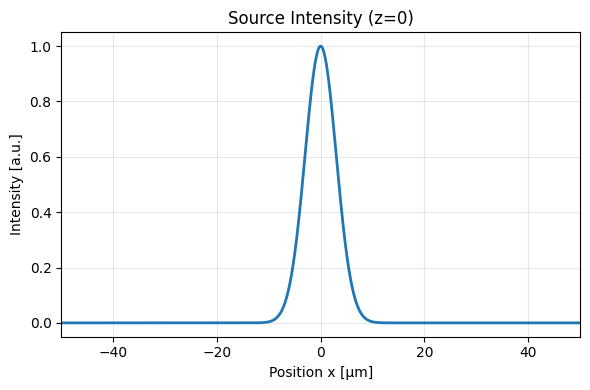

In [10]:
# Define an initial Gaussian beam
source_sigma_m = source_fwhm_m / (2 * np.sqrt(2 * np.log(2)))
E_source = gaussfunc(x_m, mean_x=0, sigma_x=source_sigma_m)

# Calculate source properties
I_source = np.abs(E_source)**2
phase_source = np.angle(E_source)

print("Source beam at z=0:")
print(f"    FWHM (specified): {source_fwhm_m*1e6:.1f} μm")
print(f"    Sigma: {source_sigma_m*1e6:.2f} μm")

# Visualize initial beam intensity only
plt.figure(figsize=(6, 4))
plt.plot(x_m*1e6, I_source, linewidth=2)
plt.xlabel('Position x [μm]')
plt.ylabel('Intensity [a.u.]')
plt.title('Source Intensity (z=0)')
plt.xlim(-50, 50)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Propagation of a Gaussian beam

__Goal:__ Understand how a Gaussian beam evolves in free space due to diffraction.

__Method:__ Propagate a 10 μm FWHM Gaussian source using the Transfer Function method, tracking both intensity and phase evolution.

Beam at grating (z=2.0 m):
  FWHM (expected): 218.9 μm
  Peak intensity: 0.023 a.u.


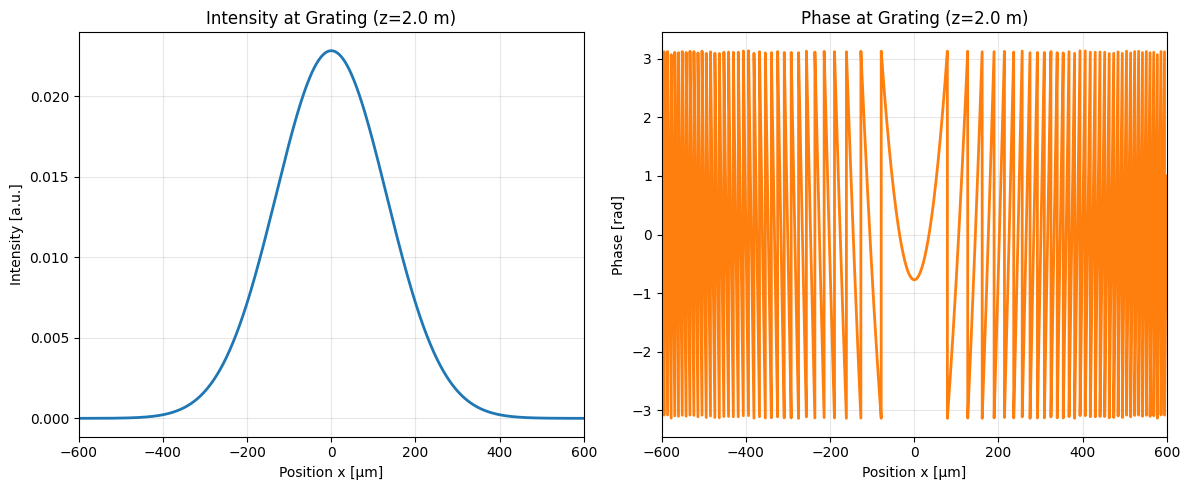

In [11]:
# Propagate source to grating using Transfer Function method
E_at_grating = propTF(E_source, L_m, wavelength_m, z_to_grating_m)

# Calculate beam properties at grating
I_at_grating = np.abs(E_at_grating)**2
phase_at_grating = np.angle(E_at_grating)

print(f"Beam at grating (z={z_to_grating_m} m):")
print(f"  FWHM (expected): {beam_fwhm_grating*1e6:.1f} μm")
print(f"  Peak intensity: {np.max(I_at_grating):.3f} a.u.")

# Visualize beam at grating
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Intensity
ax = axes[0]
ax.plot(x_m*1e6, I_at_grating, linewidth=2)
ax.set_xlabel('Position x [μm]')
ax.set_ylabel('Intensity [a.u.]')
ax.set_title(f'Intensity at Grating (z={z_to_grating_m} m)')
ax.set_xlim(-600, 600)
ax.grid(True, alpha=0.3)

# Phase
ax = axes[1]
ax.plot(x_m*1e6, phase_at_grating, linewidth=2, color='C1')
ax.set_xlabel('Position x [μm]')
ax.set_ylabel('Phase [rad]')
ax.set_title(f'Phase at Grating (z={z_to_grating_m} m)')
ax.set_xlim(-600, 600)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Propagated to 10 distances
Distance range: 0.10 to 2.80 m


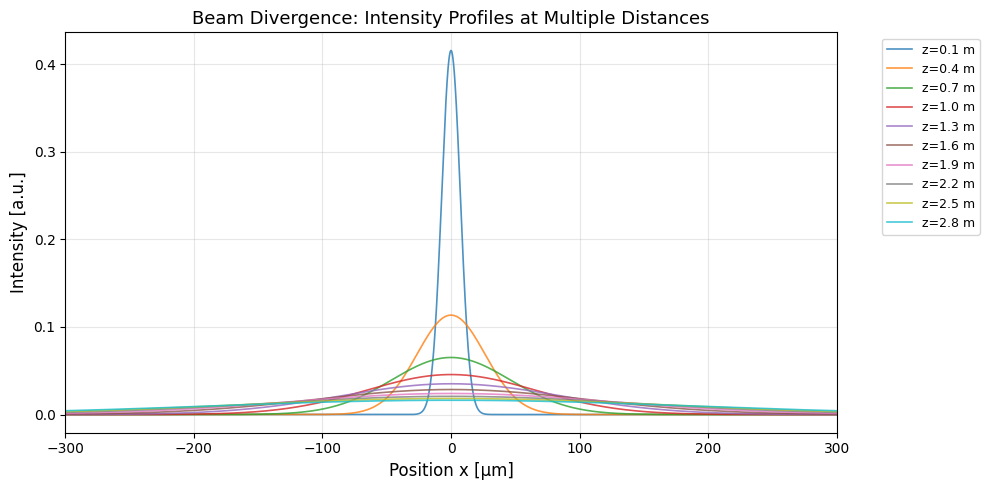

In [12]:
# Propagate to Multiple Distances f

# Define propagation distances for comparison
z_array = np.linspace(0.1, 2.8, 10)  # 10 distances from 0.1 to 2.8 m

# Propagate and store results
E_list = []
for z in z_array:
    E_prop = propTF(E_source, L_m, wavelength_m, z)
    E_list.append(E_prop)

print(f"Propagated to {len(z_array)} distances")
print(f"Distance range: {z_array[0]:.2f} to {z_array[-1]:.2f} m")

# Plot 1: Overlaid intensity profiles
plt.figure(figsize=(10, 5))
for i, (z, E) in enumerate(zip(z_array, E_list)):
    intensity = np.abs(E)**2
    plt.plot(x_m*1e6, intensity, linewidth=1.2, alpha=0.8, label=f'z={z:.1f} m')

plt.xlabel('Position x [μm]', fontsize=12)
plt.ylabel('Intensity [a.u.]', fontsize=12)
plt.title('Beam Divergence: Intensity Profiles at Multiple Distances', fontsize=13)
plt.xlim(-300, 300)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


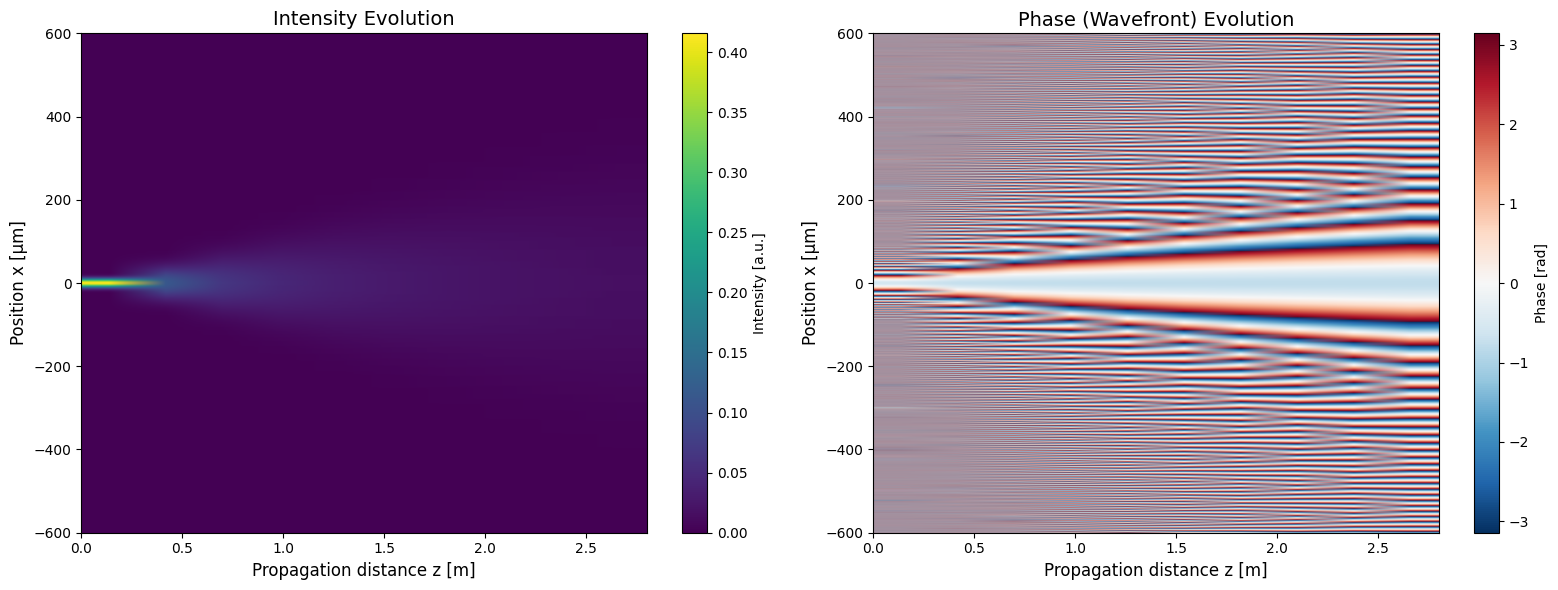

In [13]:
# 2D Propagation Visualization (Source → Grating)

I_matrix = np.abs(np.array(E_list).T)**2
phase_matrix = np.angle(np.array(E_list).T)

# Create side-by-side 2D visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
extent = [0, z_array[-1], x_m[0]*1e6, x_m[-1]*1e6]

# Left: Intensity evolution
im1 = ax1.imshow(I_matrix, 
                 extent=extent,
                 aspect='auto',
                 origin='lower',
                 interpolation='bilinear')
ax1.set_xlabel('Propagation distance z [m]', fontsize=12)
ax1.set_ylabel('Position x [μm]', fontsize=12)
ax1.set_title('Intensity Evolution', fontsize=14)
ax1.set_ylim(-600, 600)
plt.colorbar(im1, ax=ax1, label='Intensity [a.u.]')

# Right: Phase (wavefront) evolution
im2 = ax2.imshow(phase_matrix, 
                 extent=extent,
                 aspect='auto',
                 origin='lower',
                 cmap='RdBu_r',
                 interpolation='bilinear',
                 vmin=-np.pi, vmax=np.pi)
ax2.set_xlabel('Propagation distance z [m]', fontsize=12)
ax2.set_ylabel('Position x [μm]', fontsize=12)
ax2.set_title('Phase (Wavefront) Evolution', fontsize=14)
ax2.set_ylim(-600, 600)
plt.colorbar(im2, ax=ax2, label='Phase [rad]')

plt.tight_layout()
plt.show()


Also calculate __ground truth__ for future comparison. We compute the wavefront at two planes:

- **Grating plane** ($z = z_\text{to grating}$): the input to the shearing/diffraction chain.
- **Detector plane** ($z = z_\text{to grating} + z_T$): where the fringes are measured. With the practical reconstruction strategy (using the actual grating pitch $p$ in the formulas), this is the plane the recovered $W(x)$ corresponds to.

The two wavefronts differ by the geometric fringe magnification $M = (R_1 + z_T)/R_1$ — for a diverging beam, the detector-plane wavefront has *smaller* curvature than the grating-plane one (longer radius of curvature, by a factor of $M$). Both share the same aberration content; the choice of plane is essentially a labeling convention.

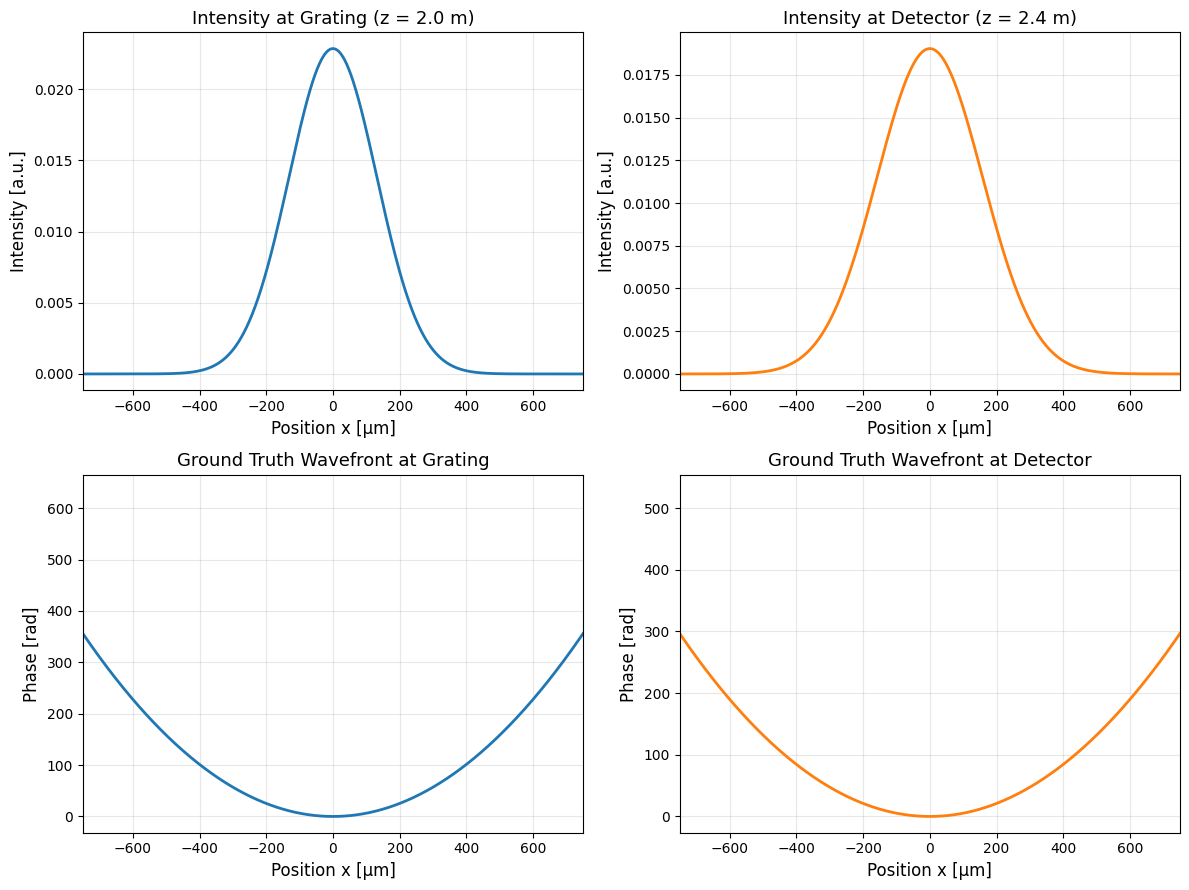

Geometric fringe magnification: M = (R_1 + z_T)/R_1 = 1.200
Phase at x = 100.1 μm:
  At grating:  6.34 rad
  At detector: 5.28 rad
  Ratio (det/grat): 0.833
  Expected (1/M):   0.833


In [14]:
# Propagate source to both planes for ground-truth comparison
E_ground_truth_grating  = propTF(E_source, L_m, wavelength_m, z_to_grating_m)
E_ground_truth_detector = propTF(E_source, L_m, wavelength_m, z_to_grating_m + z_T_m)

# Unwrapped, centered phase at each plane
phase_ground_truth_centered_grating = (
    np.unwrap(np.angle(E_ground_truth_grating))
    - np.unwrap(np.angle(E_ground_truth_grating))[M//2]
)
phase_ground_truth_centered_detector = (
    np.unwrap(np.angle(E_ground_truth_detector))
    - np.unwrap(np.angle(E_ground_truth_detector))[M//2]
)

# Plot intensity and phase at both planes
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Top row: intensity
ax = axes[0, 0]
ax.plot(x_m*1e6, np.abs(E_ground_truth_grating)**2, linewidth=2)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Intensity [a.u.]', fontsize=12)
ax.set_title(f'Intensity at Grating (z = {z_to_grating_m:.1f} m)', fontsize=13)
ax.set_xlim(-750, 750)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(x_m*1e6, np.abs(E_ground_truth_detector)**2, linewidth=2, color='C1')
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Intensity [a.u.]', fontsize=12)
ax.set_title(f'Intensity at Detector (z = {z_to_grating_m + z_T_m:.1f} m)', fontsize=13)
ax.set_xlim(-750, 750)
ax.grid(True, alpha=0.3)

# Bottom row: phase
ax = axes[1, 0]
ax.plot(x_m*1e6, phase_ground_truth_centered_grating, linewidth=2)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Phase [rad]', fontsize=12)
ax.set_title('Ground Truth Wavefront at Grating', fontsize=13)
ax.set_xlim(-750, 750)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(x_m*1e6, phase_ground_truth_centered_detector, linewidth=2, color='C1')
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Phase [rad]', fontsize=12)
ax.set_title('Ground Truth Wavefront at Detector', fontsize=13)
ax.set_xlim(-750, 750)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Sanity check: the two wavefronts should differ by the magnification factor
# M = (R_1 + z_T)/R_1, with W_detector / W_grating = 1/M = R_1 / R
# (longer radius at detector → flatter wavefront)
M_geom = (z_to_grating_m + z_T_m) / z_to_grating_m
idx_eval = M//2 + 1000   # ≈ 100 μm off-center, well within the beam
print(f"Geometric fringe magnification: M = (R_1 + z_T)/R_1 = {M_geom:.3f}")
print(f"Phase at x = {x_m[idx_eval]*1e6:.1f} μm:")
print(f"  At grating:  {phase_ground_truth_centered_grating[idx_eval]:.2f} rad")
print(f"  At detector: {phase_ground_truth_centered_detector[idx_eval]:.2f} rad")
print(f"  Ratio (det/grat): {phase_ground_truth_centered_detector[idx_eval]/phase_ground_truth_centered_grating[idx_eval]:.3f}")
print(f"  Expected (1/M):   {1/M_geom:.3f}")

## Applying Shearing Grating

**Goal:** Introduce periodic amplitude modulation to create ±1 diffraction orders that will interfere at the Talbot distance

__Talbot self-imaging:__ Multiply the beam by a binary amplitude grating with pitch p = 31.5 μm, satisfying the Talbot condition $z_T = p^2/\lambda$.

**Key parameters:**
- Grating pitch: 31.5 μm (from Talbot condition)
- Talbot distance: 0.4 m (matches Wojdyla 2018)
- Measurement plane: z = 2 m from source


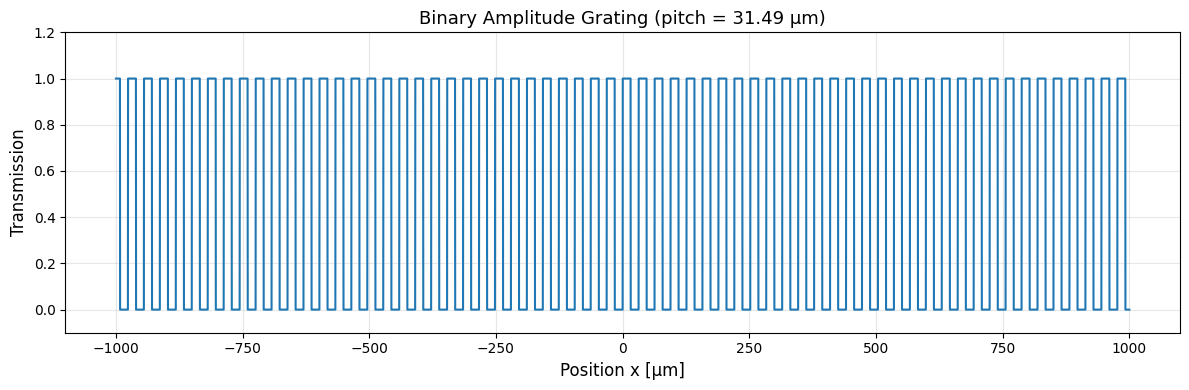

In [15]:
# Create binary grating: 0 (blocked) and 1 (transmitted)
grating_pattern = (np.sign(np.sin(2*np.pi*x_m/grating_pitch_m)) + 1) / 2

# Visualize grating pattern
plt.figure(figsize=(12, 4))
plt.plot(x_m*1e6, grating_pattern, linewidth=1.5)
plt.xlabel('Position x [μm]', fontsize=12)
plt.ylabel('Transmission', fontsize=12)
plt.title(f'Binary Amplitude Grating (pitch = {grating_pitch_m*1e6:.2f} μm)', fontsize=13)
# plt.xlim(-600, 600) 
plt.ylim(-0.1, 1.2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


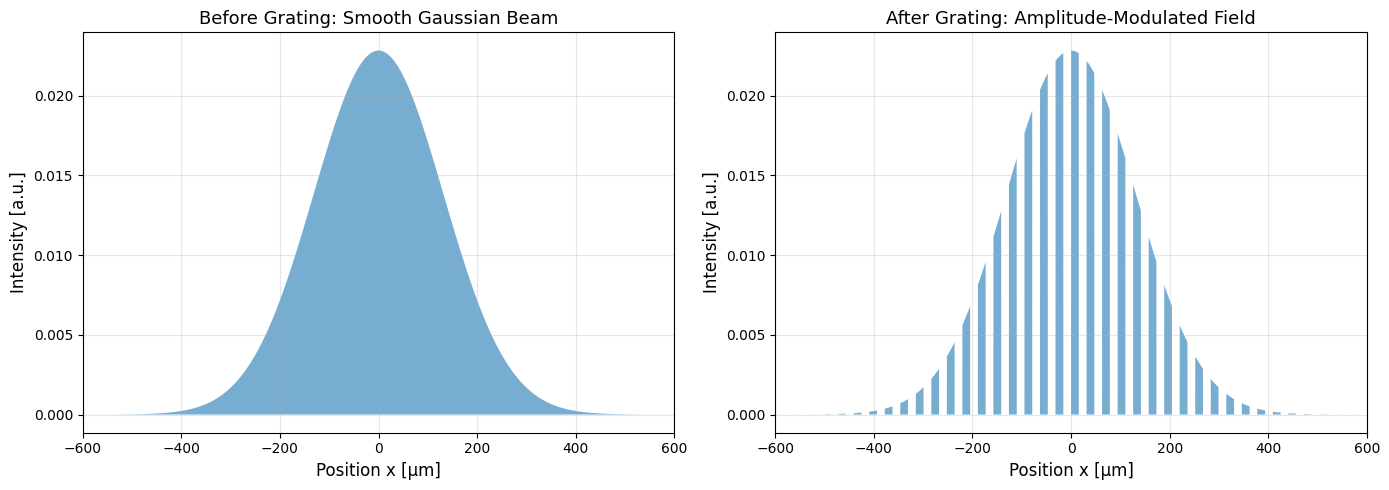

In [16]:
# Apply Grating: Amplitude Modulation

# Multiply beam by grating (creates ±1 diffraction orders)
E_modulated = E_at_grating * grating_pattern

# Calculate intensities
I_before = np.abs(E_at_grating)**2
I_after = np.abs(E_modulated)**2

# Visualize before and after modulation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: Smooth beam
ax = axes[0]
ax.fill_between(x_m*1e6, 0, I_before, alpha=0.6)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Intensity [a.u.]', fontsize=12)
ax.set_title('Before Grating: Smooth Gaussian Beam', fontsize=13)
ax.set_xlim(-600, 600)
ax.grid(True, alpha=0.3)

# After: Modulated beam
ax = axes[1]
ax.fill_between(x_m*1e6, 0, I_after, alpha=0.6)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Intensity [a.u.]', fontsize=12)
ax.set_title('After Grating: Amplitude-Modulated Field', fontsize=13)
ax.set_xlim(-600, 600)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Post-Grating

### Propagation to Talbot plane

__Goal:__ 
Observe Talbot self-imaging - the interference fringes that form when ±1 diffraction orders overlap at the Talbot distance.

__Physics:__
The grating-modulated field propagates through free space. At 
$ z = z_\text{T} = p²/\lambda $
, constructive interference between diffraction orders creates sharp fringes with maximum contrast. This fringe pattern encodes the wavefront slope information needed for reconstruction.

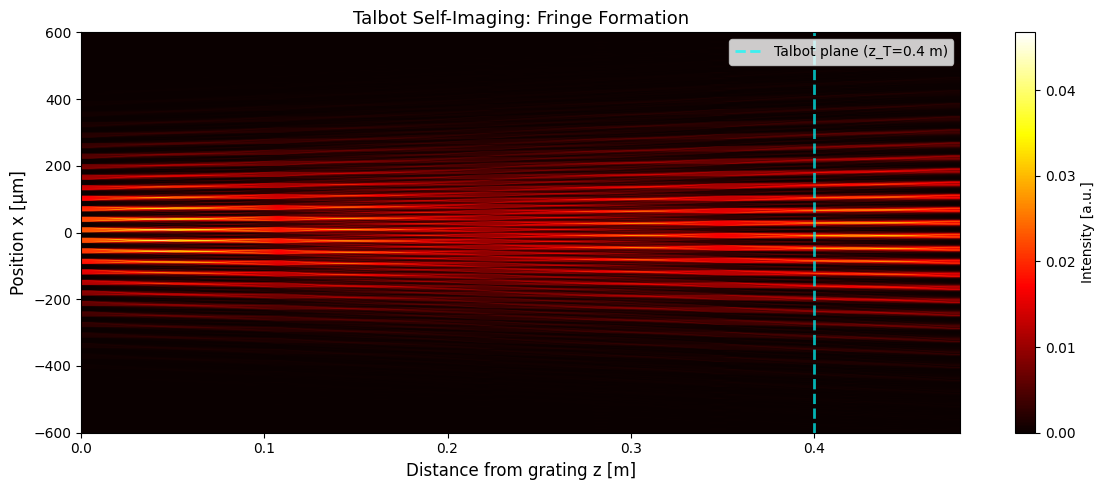

In [17]:
# 2D Visualization

# Propagate modulated field with fine z-sampling
n_steps = 60
z_array_post = np.linspace(0, z_T_m*1.2, n_steps)
E_list_post = []

for z in z_array_post:
    E_z = propTF(E_modulated, L_m, wavelength_m, z)
    E_list_post.append(E_z)

# Create 2D intensity map
I_matrix_post = np.abs(np.array(E_list_post).T)**2

# Visualize fringe formation
fig, ax = plt.subplots(figsize=(12, 5))
extent = [z_array_post[0], z_array_post[-1], x_m[0]*1e6, x_m[-1]*1e6]

im = ax.imshow(I_matrix_post, 
               extent=extent, 
               aspect='auto',
               origin='lower',
               cmap='hot')

ax.set_xlabel('Distance from grating z [m]', fontsize=12)
ax.set_ylabel('Position x [μm]', fontsize=12)
ax.set_title('Talbot Self-Imaging: Fringe Formation', fontsize=13)
ax.set_ylim(-600, 600)

# Mark Talbot distance
ax.axvline(z_T_m, color='cyan', linestyle='--', linewidth=2, 
           alpha=0.7, label=f'Talbot plane (z_T={z_T_m} m)')
ax.legend(loc='upper right', fontsize=10)

plt.colorbar(im, ax=ax, label='Intensity [a.u.]')
plt.tight_layout()
plt.show()


__Curvature-Corrected Talbot Distance__

For a diverging Gaussian beam, the wavefront has curvature. The effective Talbot distance shifts according to:
$ 1/z_\text{C} = 1/z_\text{T} - 1/R $, where $R$ is negative in our case. For a Gaussian beam:
$$ R = z \left( 1 + \frac{z_\text{R}}{z} \right)^2 $$


In [18]:
# Calculate Curvature-Corrected Talbot Distance (z_C)

# Wavefront radius of curvature at grating
R_at_grating = -z_to_grating_m * (1 + (z_rayleigh / z_to_grating_m)**2)

# Curvature-corrected Talbot distance
z_C_m = 1 / (1/z_T_m - 1/R_at_grating)

print(f"Radius of curvature at grating: {R_at_grating:.4f} m")
print(f"z_T (standard):              {z_T_m:.4f} m")
print(f"z_C (curvature-corrected):   {z_C_m:.4f} m")

Radius of curvature at grating: -2.0042 m
z_T (standard):              0.4000 m
z_C (curvature-corrected):   0.3334 m


Fringe contrast comparison:
  At z_T = 0.400 m: 0.9877
  At z_C = 0.333 m: 0.9030


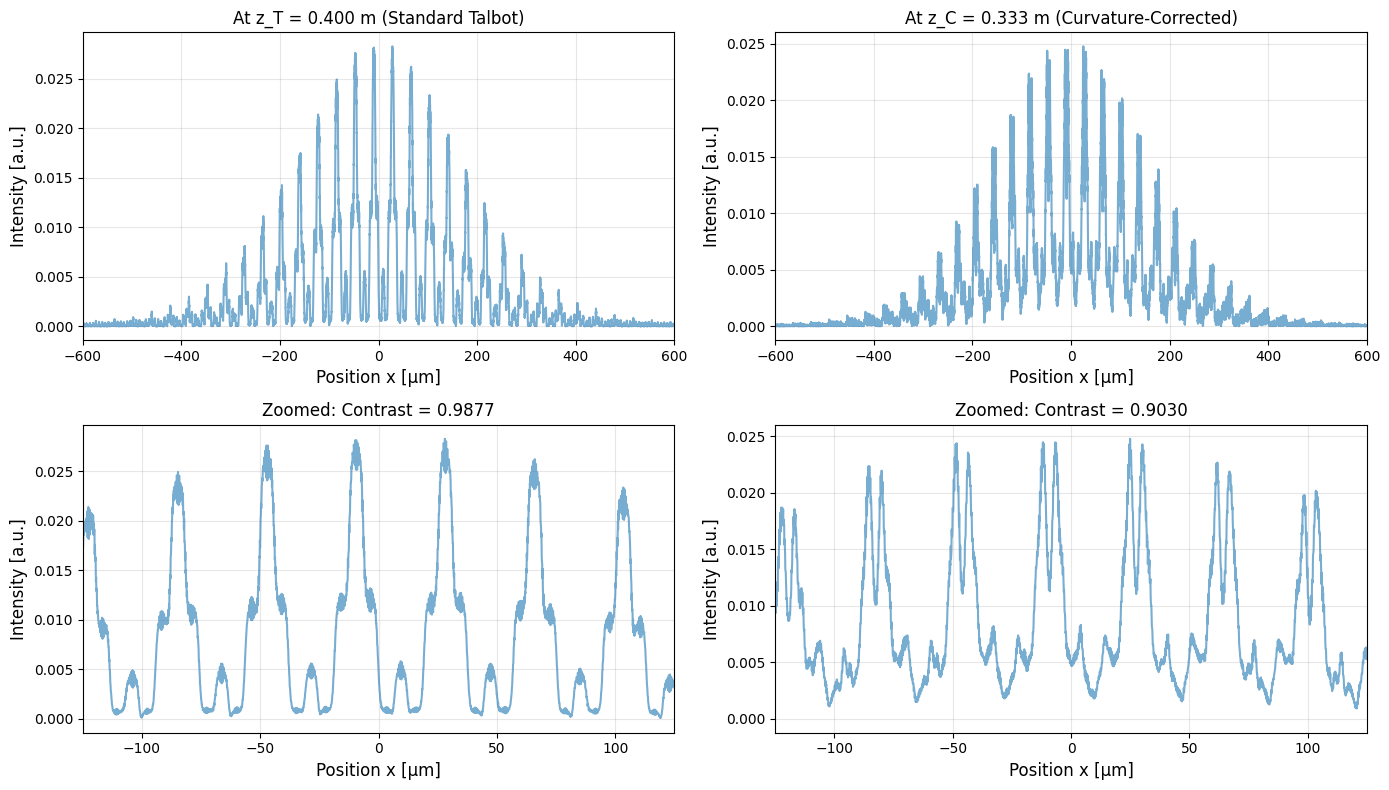

In [19]:
# Compare Fringe Patterns at z_T vs z_C

# Propagate to both distances
E_at_z_T = propTF(E_modulated, L_m, wavelength_m, z_T_m)
E_at_z_C = propTF(E_modulated, L_m, wavelength_m, z_C_m)

I_at_z_T = np.abs(E_at_z_T)**2
I_at_z_C = np.abs(E_at_z_C)**2

# Calculate fringe contrast in central region
center_region = (np.abs(x_m) < 100e-6)
I_center_T = I_at_z_T[center_region]
I_center_C = I_at_z_C[center_region]

contrast_z_T = (np.max(I_center_T) - np.min(I_center_T)) / (np.max(I_center_T) + np.min(I_center_T))
contrast_z_C = (np.max(I_center_C) - np.min(I_center_C)) / (np.max(I_center_C) + np.min(I_center_C))

print(f"Fringe contrast comparison:")
print(f"  At z_T = {z_T_m:.3f} m: {contrast_z_T:.4f}")
print(f"  At z_C = {z_C_m:.3f} m: {contrast_z_C:.4f}")

# Visualize side-by-side comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Full view at z_T
ax = axes[0, 0]
ax.plot(x_m*1e6, I_at_z_T, alpha=0.6)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Intensity [a.u.]', fontsize=12)
ax.set_title(f'At z_T = {z_T_m:.3f} m (Standard Talbot)', fontsize=12)
ax.set_xlim(-600, 600)
ax.grid(True, alpha=0.3)

# Zoomed view at z_T
ax = axes[1, 0]
ax.plot(x_m*1e6, I_at_z_T, alpha=0.6)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Intensity [a.u.]', fontsize=12)
ax.set_title(f'Zoomed: Contrast = {contrast_z_T:.4f}', fontsize=12)
ax.set_xlim(-125, 125)
ax.grid(True, alpha=0.3)

# Full view at z_C
ax = axes[0, 1]
ax.plot(x_m*1e6, I_at_z_C, alpha=0.6)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Intensity [a.u.]', fontsize=12)
ax.set_title(f'At z_C = {z_C_m:.3f} m (Curvature-Corrected)', fontsize=12)
ax.set_xlim(-600, 600)
ax.grid(True, alpha=0.3)

# Zoomed view at z_C
ax = axes[1, 1]
ax.plot(x_m*1e6, I_at_z_C, alpha=0.6)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Intensity [a.u.]', fontsize=12)
ax.set_title(f'Zoomed: Contrast = {contrast_z_C:.4f}', fontsize=12)
ax.set_xlim(-125, 125)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Wavefront reconstruction

__Goal:__ Extract the wavefront $W(x)$ at the **detector plane** from the interference pattern.

__Physical Principle:__

For lateral shearing interferometry, the measured intensity is:
$$I(x) = I_0(x) + I_1(x) \cos[2\pi f_C x + \Delta\phi(x)]$$
where $f_C = 1/p$ is the carrier frequency set by the grating pitch $p$, and $\Delta\phi(x)$ is the differential phase between the interfering ±1 orders. The differential phase relates to the wavefront slope through the shear distance $s = \lambda z_T / p$ (Momose 2003):
$$\Delta\phi(x) = \frac{\lambda z_T}{p}\,\frac{\partial W}{\partial x} \;\;\Longrightarrow\;\; W(x) = \frac{p}{\lambda z_T}\int \Delta\phi(x)\,dx \quad [\text{rad}]$$

___

__A note on the reconstruction plane:__

For a diverging beam, the fringes at the detector are geometrically magnified by $M = (R_1 + z_T)/R_1$, so the FFT-measured carrier sits at $f_C^\text{measured} = 1/(pM)$ rather than at $1/p$. This is purely a viewing-geometry effect — the physical shear is still $\lambda z_T/p$.

We use the **ideal pitch $p$** in the formulas, which recovers $W$ at the **detector plane** (Gaussian curvature + aberrations included). This choice is robust because $p$ is known precisely from fabrication, while $f_C^\text{measured}$ is a noisy peak fit. Using $p_\text{eff} = pM$ instead would recover $W$ at the grating plane — equally valid mathematically, but requires accurate knowledge of $R_1$.

**Important:** the carrier ramp to subtract before integration is always $2\pi f_C^\text{ideal} x$, regardless of which plane convention is used. Subtracting the *measured* carrier would also remove the linear contribution from the wavefront curvature, leaving $\Delta\phi \approx 0$.

___

__Reconstruction Strategy:__

1. **FFT** $I(x)$ → frequency domain. Locate the +1 order peak (sits near $f_C^\text{measured}$).
2. **Bandpass filter**: isolate the +1 order with a Gaussian centered at the detected peak.
3. **IFFT**: angle of the complex result is $2\pi f_C^\text{ideal} x + \Delta\phi(x)$, wrapped.
4. **Unwrap and re-center** at $x = 0$.
5. **Carrier removal**: subtract $2\pi (1/p)\,x$ to isolate $\Delta\phi(x)$.
6. **Integrate** with scaling $p/(\lambda z_T)$ to get $W(x)$ at the detector.

__Underlying math:__

The interference pattern can be written as:
$$ I(x) = I_0(x) + I_1(x)\cos[2\pi f_C^\text{ideal} x + \Delta\phi(x)] $$

Filtering the +1 peak of $\mathcal{F}\{I\}$ and inverse-transforming gives a complex envelope:
$$ s(x) = \tfrac{1}{2} I_1(x)\, e^{i\Delta\phi(x)}\, e^{2\pi i f_C^\text{ideal} x} $$
whose angle is the carrier ramp plus the differential phase:
$$ \angle s(x) = 2\pi f_C^\text{ideal} x + \Delta\phi(x) $$

The carrier ramp $2\pi f_C^\text{ideal} x$ is removed before integration to recover $W(x)$.

FFT Analysis:
    +1 order carrier frequency: 26.50 cycles/mm
    Carrier index: 10053
    Comparison: Pitch & wavelength --> 31.75 cycles/mm


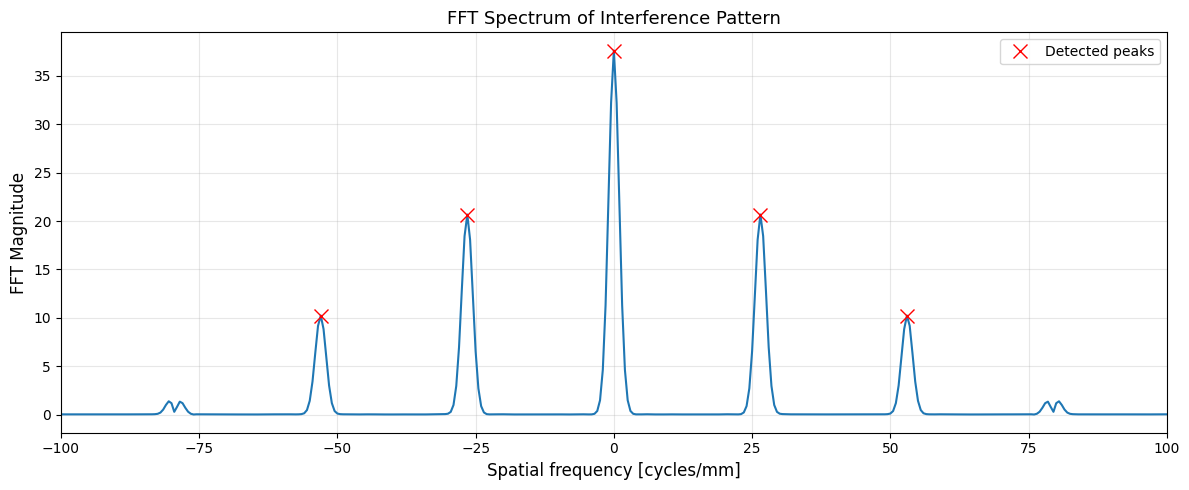

In [20]:
# Transform intensity pattern to frequency domain
I_fft = np.fft.fftshift(np.fft.fft(I_at_z_T))

# Create frequency array
df = 1 / L_m  # Frequency resolution [1/m]
freq = np.fft.fftshift(np.fft.fftfreq(M, dx_m))

# Find peaks in FFT spectrum (use magnitude)
I_fft_magnitude = np.abs(I_fft)
peaks, properties = find_peaks(I_fft_magnitude, height=np.max(I_fft_magnitude)*0.1)

# Identify carrier frequency (should be at ±1/pitch)
carrier_freq_ideal = 1 / grating_pitch_m
carrier_idx = peaks[np.argmin(np.abs(freq[peaks] - carrier_freq_ideal))]
carrier_freq_measured = freq[carrier_idx]

print(f"FFT Analysis:")
print(f"    +1 order carrier frequency: {carrier_freq_measured*1e-3:.2f} cycles/mm")
print(f"    Carrier index: {carrier_idx}")
print(f"    Comparison: Pitch & wavelength --> {carrier_freq_ideal*1e-3:.2f} cycles/mm")

# Visualize FFT spectrum
plt.figure(figsize=(12, 5))
plt.plot(freq*1e-3, I_fft_magnitude, linewidth=1.5)
plt.plot(freq[peaks]*1e-3, I_fft_magnitude[peaks], 'rx', markersize=10, label='Detected peaks')
plt.xlabel('Spatial frequency [cycles/mm]', fontsize=12)
plt.ylabel('FFT Magnitude', fontsize=12)
plt.title('FFT Spectrum of Interference Pattern', fontsize=13)
plt.xlim(-100, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

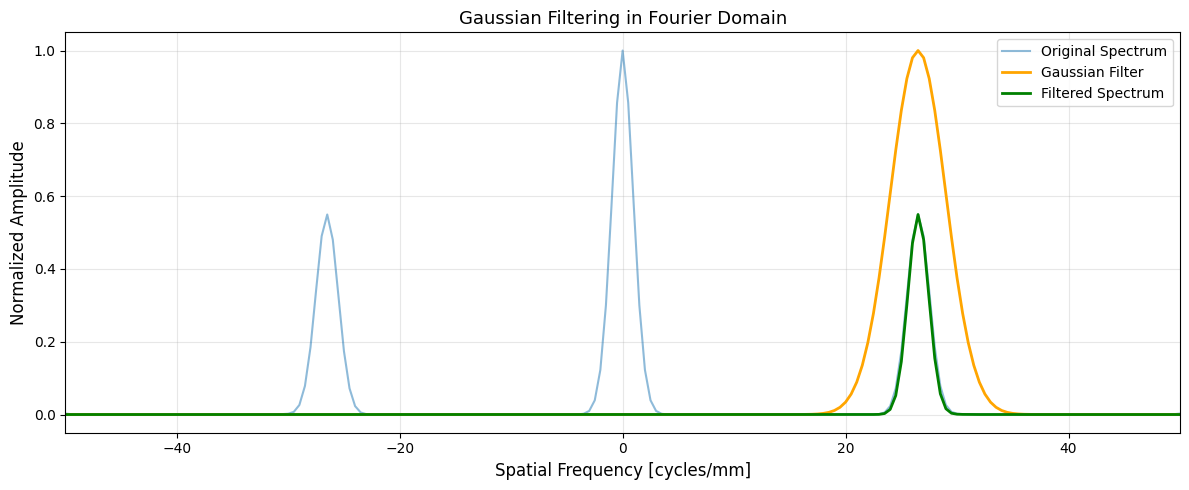

In [21]:
# Create Gaussian filter centered on +1 order
filter_width = 5.0  # pixels (standard deviation)
x_indices = np.arange(M)
gaussian_filter = np.exp(-0.5 * ((x_indices - carrier_idx) / filter_width)**2)

# Apply filter to FFT
I_fft_filtered = I_fft * gaussian_filter

# Normalize for visualization (so all curves are visible on same plot)
I_fft_magnitude_norm = I_fft_magnitude / np.max(I_fft_magnitude)
I_fft_filtered_norm = np.abs(I_fft_filtered) / np.max(np.abs(I_fft_magnitude))

# Visualize filtering
plt.figure(figsize=(12, 5))
plt.plot(freq*1e-3, I_fft_magnitude_norm, label='Original Spectrum', alpha=0.5)
plt.plot(freq*1e-3, gaussian_filter, label='Gaussian Filter', linewidth=2, color='orange')
plt.plot(freq*1e-3, I_fft_filtered_norm, 
         label='Filtered Spectrum', linewidth=2, color='green')
plt.xlabel('Spatial Frequency [cycles/mm]', fontsize=12)
plt.ylabel('Normalized Amplitude', fontsize=12)
plt.title('Gaussian Filtering in Fourier Domain', fontsize=13)
plt.xlim(-50, 50)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

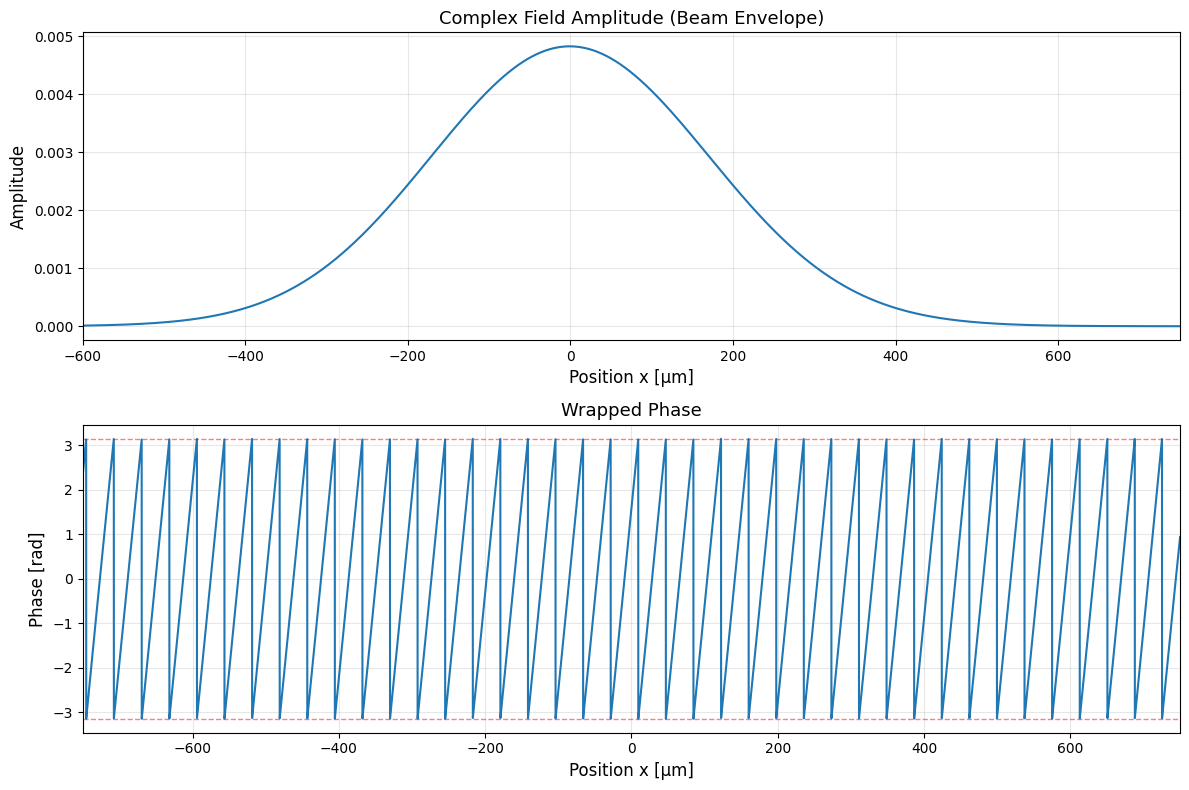

In [22]:
# Inverse FFT to get complex field
complex_field = np.fft.ifft(np.fft.ifftshift(I_fft_filtered))

# Extract amplitude and wrapped phase
amplitude = np.abs(complex_field)
phase_wrapped = np.angle(complex_field)

# Visualize complex field
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Amplitude (beam envelope)
ax = axes[0]
ax.plot(x_m*1e6, amplitude, linewidth=1.5)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Amplitude', fontsize=12)
ax.set_title('Complex Field Amplitude (Beam Envelope)', fontsize=13)
ax.set_xlim(-600, 750)
ax.grid(True, alpha=0.3)

# Wrapped phase
ax = axes[1]
ax.plot(x_m*1e6, phase_wrapped, linewidth=1.5)
ax.axhline(np.pi, color='r', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(-np.pi, color='r', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Phase [rad]', fontsize=12)
ax.set_title('Wrapped Phase', fontsize=13)
ax.set_xlim(-750, 750)
ax.set_ylim(-np.pi*1.1, np.pi*1.1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

__Step 2:__ Phase unwrapping

The arctangent function wraps phase to $[-\pi, +\pi)$, creating $2\pi$ discontinuities. We unwrap with `np.unwrap` (left-to-right) and then re-center at $x = 0$ by subtracting the value at index `M//2`. This removes the piston term (overall offset) and ensures `phase_centered[M//2] = 0`, leaving us with $2\pi f_\text{C} x + \Delta\phi(x)$ ready for carrier removal in Step 3.

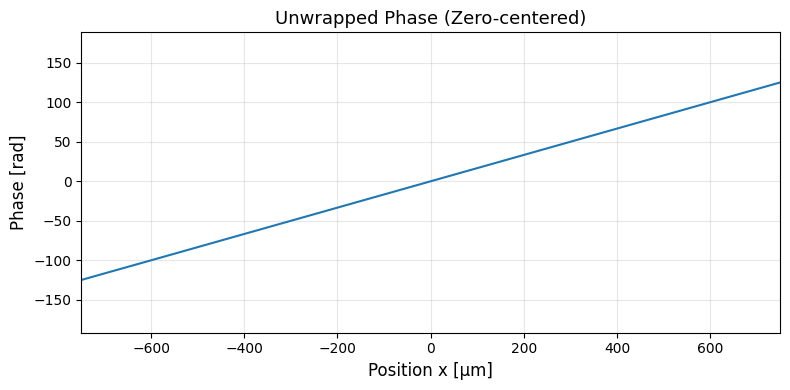

In [23]:
# Standard unwrap (left-to-right) and center at x=0
phase_unwrapped = np.unwrap(phase_wrapped)
phase_centered = phase_unwrapped - phase_unwrapped[M//2]

# Visualize only the unwrapped and centered phase
plt.figure(figsize=(8, 4))
plt.plot(x_m*1e6, phase_centered, linewidth=1.5)
plt.xlabel('Position x [μm]', fontsize=12)
plt.ylabel('Phase [rad]', fontsize=12)
plt.title('Unwrapped Phase (Zero-centered)', fontsize=13)
plt.xlim(-750, 750)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


__Step 3:__ Carrier removal, integration, and comparison

The unwrapped phase from Step 2 is $2\pi f_C^\text{ideal}\, x + \Delta\phi(x)$ — the bare grating carrier ramp plus the wavefront-slope differential phase. To recover the wavefront:

1. **Remove the carrier**: subtract $2\pi (1/p)\, x$ — using the ideal pitch $p$, *not* the FFT-measured frequency — to isolate $\Delta\phi(x)$.
2. **Integrate** with the correct scaling:
$$W(x) = \frac{p}{\lambda z_T} \int \Delta\phi(x)\,dx \quad [\text{rad}]$$
3. **Re-center** at $x = 0$ to remove the integration constant (piston).

The result $W(x)$ is the wavefront at the **detector plane**, validated against `phase_ground_truth_centered_detector`.

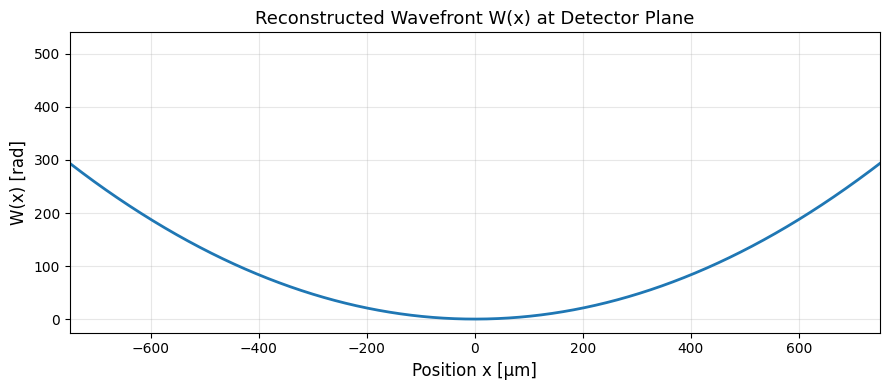

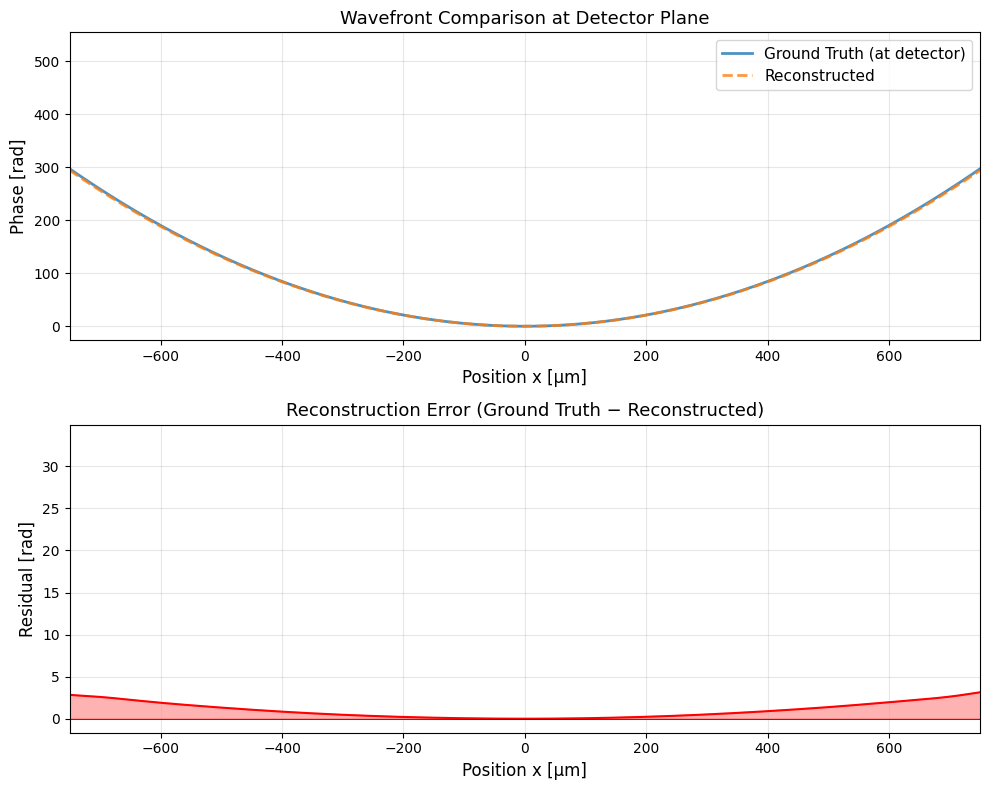

In [24]:
# Step 1: Remove carrier ramp using the IDEAL pitch (= 2π/p) to isolate Δφ(x)
# Using the FFT-measured frequency here would zero out the wavefront curvature.
carrier_ramp = 2 * np.pi * (1 / grating_pitch_m) * x_m
carrier_ramp_centered = carrier_ramp - carrier_ramp[M//2]
delta_phi = phase_centered - carrier_ramp_centered

# Step 2: Integrate to get W(x) at the detector plane
# W(x) = (p / λ z_T) ∫ Δφ(x) dx   [rad]
# (sign: with phase_centered's sign convention from np.angle, integration carries
wavefront_temp = -np.cumsum(delta_phi) * dx_m * grating_pitch_m / wavelength_m / z_T_m

# Step 3: Re-center at x=0 to remove integration constant (piston)
wavefront_reconstructed = wavefront_temp - wavefront_temp[M//2]

# Plot reconstructed wavefront
plt.figure(figsize=(9, 4))
plt.plot(x_m*1e6, wavefront_reconstructed, linewidth=2)
plt.xlabel('Position x [μm]', fontsize=12)
plt.ylabel('W(x) [rad]', fontsize=12)
plt.title('Reconstructed Wavefront W(x) at Detector Plane', fontsize=13)
plt.xlim(-750, 750)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare to ground truth at the detector plane
residual = phase_ground_truth_centered_detector - wavefront_reconstructed

# Plot comparison and residual
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

ax = axes[0]
ax.plot(x_m*1e6, phase_ground_truth_centered_detector, linewidth=2, label='Ground Truth (at detector)', alpha=0.8)
ax.plot(x_m*1e6, wavefront_reconstructed, linewidth=2, linestyle='--', label='Reconstructed', alpha=0.8)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Phase [rad]', fontsize=12)
ax.set_title('Wavefront Comparison at Detector Plane', fontsize=13)
ax.set_xlim(-750, 750)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_m*1e6, residual, linewidth=1.5, color='red')
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax.fill_between(x_m*1e6, 0, residual, alpha=0.3, color='red')
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Residual [rad]', fontsize=12)
ax.set_title('Reconstruction Error (Ground Truth − Reconstructed)', fontsize=13)
ax.set_xlim(-750, 750)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

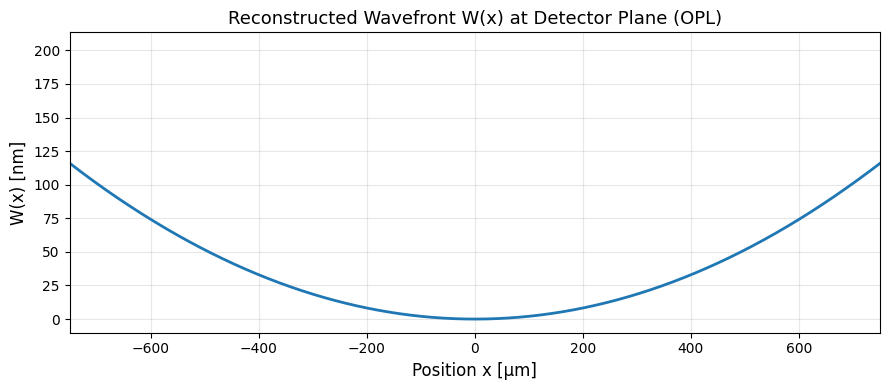

In [25]:
# Convert reconstructed wavefront from radians to optical path length (meters)
# OPL convention: W_OPL = W_rad × (λ / 2π)
wavefront_reconstructed_m = wavefront_reconstructed * wavelength_m / (2 * np.pi)

# Plot in nm
plt.figure(figsize=(9, 4))
plt.plot(x_m*1e6, wavefront_reconstructed_m * 1e9, linewidth=2)
plt.xlabel('Position x [μm]', fontsize=12)
plt.ylabel('W(x) [nm]', fontsize=12)
plt.title('Reconstructed Wavefront W(x) at Detector Plane (OPL)', fontsize=13)
plt.xlim(-750, 750)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# TEST

Using data measured by Antoine and Ken at COSMIC beamline @ ALS in 2021. 


## Physical Parameters


In [26]:
# Physical Parameters (Experimental Setup)

camera_pixel_m = 3.45e-6      # Camera pixel size [m]
magnification = 2.85          # Objective magnification (Boli optics)
dx_m = camera_pixel_m / magnification  # Effective pixel size [m]

energy_eV = 607               # Photon energy [eV]
wavelength_m = 1.23984e-6 / energy_eV

# Grating
grating_pitch_m = 22e-6      # Shearing grating pitch [m]

# Data dimensions
Nx = 1000                     # Number of pixels in 1D profile
x_m = np.arange(Nx) * dx_m   # Spatial axis [m]

print(f"Experimental Parameters:")
print(f"{'='*60}")
print(f"Wavelength: {wavelength_m*1e9:.3f} nm ({energy_eV} eV)")
print(f"Effective pixel size: {dx_m*1e6:.3f} μm")
print(f"Grating pitch: {grating_pitch_m*1e6:.1f} μm")
print(f"Spatial extent: {x_m[-1]*1e3:.2f} mm")

Experimental Parameters:
Wavelength: 2.043 nm (607 eV)
Effective pixel size: 1.211 μm
Grating pitch: 22.0 μm
Spatial extent: 1.21 mm


## Data Loading


Loaded: WFS210515-0002-025.tif
Image dimensions: 4112 × 3008 pixels


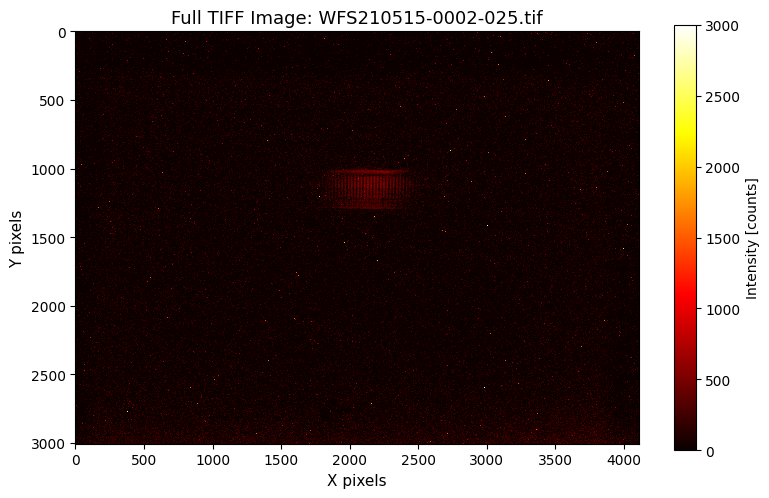

In [27]:
# Load TIFF Image
filename = "WFS210515-0002-025.tif"
im = Image.open(f'{filename}')
width, height = im.size

print(f"Loaded: {filename}")
print(f"Image dimensions: {width} × {height} pixels")

# Visualize full image
plt.figure(figsize=(8, 5))
plt.imshow(np.array(im), cmap='hot', interpolation='nearest', vmax=3000)
plt.title(f'Full TIFF Image: {filename}', fontsize=13)
plt.xlabel('X pixels', fontsize=11)
plt.ylabel('Y pixels', fontsize=11)
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

Cropped to: 1000 × 500 pixels
Row integration range: 190-240


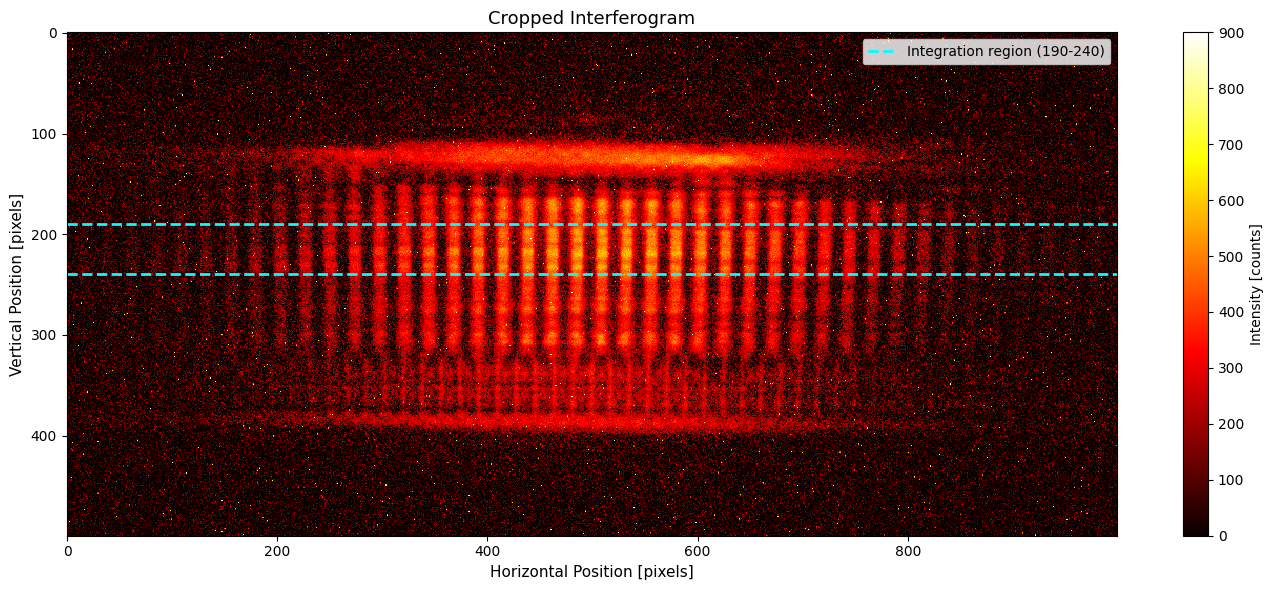

In [28]:
# Crop parameters
left, top, right, bottom = 1650, 900, 2650, 1400
row_start, row_end = 190, 240

# Crop image
im_crop = im.crop((left, top, right, bottom))
imarray = np.array(im_crop)
crop_height, crop_width = imarray.shape

print(f"Cropped to: {crop_width} × {crop_height} pixels")
print(f"Row integration range: {row_start}-{row_end}")

# Visualize cropped region
plt.figure(figsize=(14, 6))
plt.imshow(imarray, cmap='hot', aspect='auto', interpolation='nearest', vmin=0, vmax=900)
plt.axhline(row_start, color='cyan', linestyle='--', linewidth=2, 
            label=f'Integration region ({row_start}-{row_end})')
plt.axhline(row_end, color='cyan', linestyle='--', linewidth=2)
plt.title('Cropped Interferogram', fontsize=13)
plt.xlabel('Horizontal Position [pixels]', fontsize=11)
plt.ylabel('Vertical Position [pixels]', fontsize=11)
plt.colorbar(label='Intensity [counts]')
plt.legend()
plt.tight_layout()
plt.show()


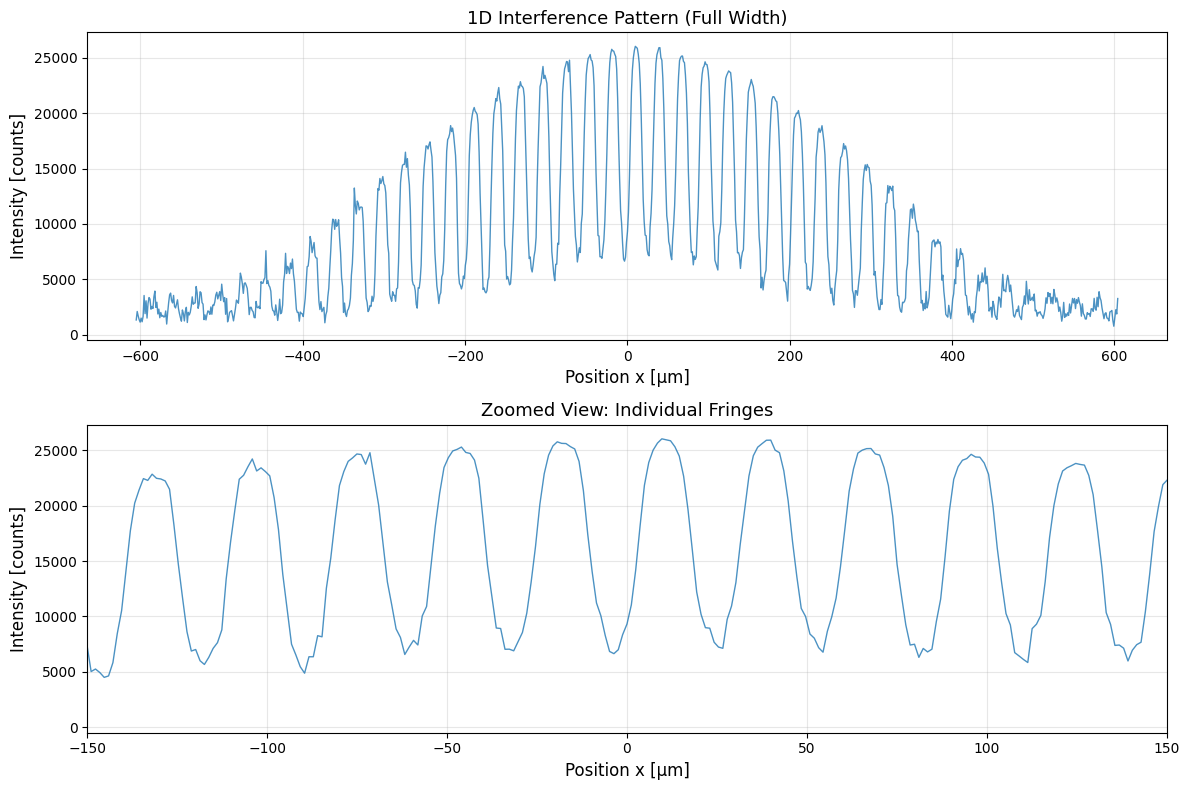

In [29]:
# Sum rows to create 1D profile (improves SNR)
I_detector = np.sum(imarray[row_start:row_end, :], axis=0)

# Update spatial axis to match data length
Nx = len(I_detector)
x_m = (np.arange(Nx) - Nx//2) * dx_m  # Centered at x=0

# Visualize 1D Interference Pattern
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Full width view
ax = axes[0]
ax.plot(x_m * 1e6, I_detector, linewidth=1, alpha=0.8)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Intensity [counts]', fontsize=12)
ax.set_title('1D Interference Pattern (Full Width)', fontsize=13)
ax.grid(True, alpha=0.3)

# Zoomed view to see individual fringes
ax = axes[1]
ax.plot(x_m * 1e6, I_detector, linewidth=1, alpha=0.8)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Intensity [counts]', fontsize=12)
ax.set_title('Zoomed View: Individual Fringes', fontsize=13)
ax.set_xlim(-150, 150)  # ±150 μm window
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# Fringe Quality Check
# Calculate fringe contrast in central region
center_mask = np.abs(x_m) < 600e-6  # Central ±300 μm
I_max = np.max(I_detector[center_mask])
I_min = np.min(I_detector[center_mask])
contrast = (I_max - I_min) / (I_max + I_min)

print(f"Fringe contrast: {contrast:.3f}")


Fringe contrast: 0.943


## Phase Reconstruction 


Carrier frequency: 34.7 cycles/mm


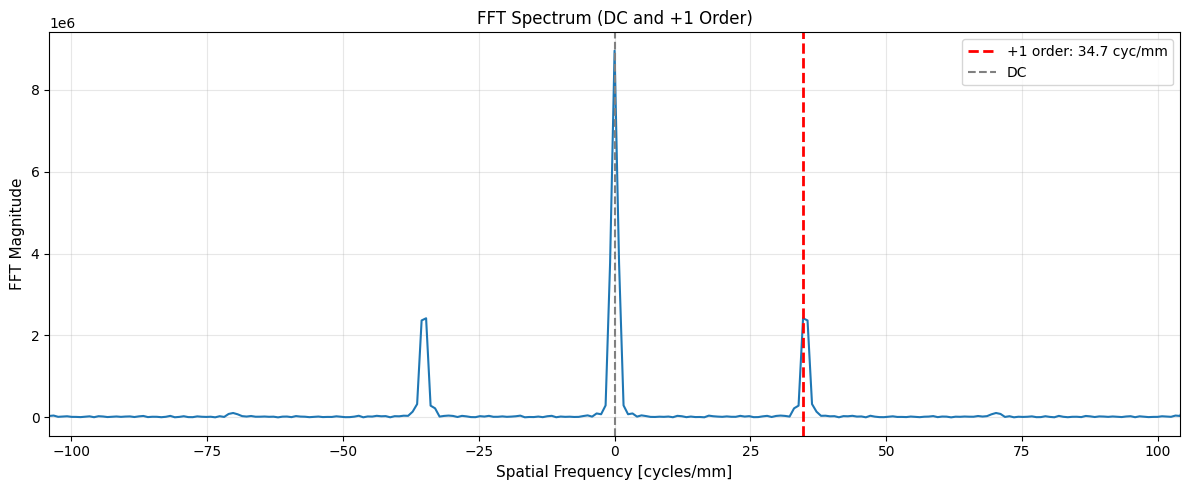

In [30]:
# FFT with proper shifts
fft_result = np.fft.fftshift(np.fft.fft(np.fft.fftshift(I_detector)))
freq_x = np.fft.fftshift(np.fft.fftfreq(Nx, dx_m))
fft_magnitude = np.abs(fft_result)

# Find carrier peak - exclude DC region
dc_exclude_width = 5000  # Exclude ±5000 cyc/m around DC
search_mask = np.abs(freq_x) > dc_exclude_width

# Find highest peak in positive frequencies
fft_search = np.zeros_like(fft_magnitude)
fft_search[search_mask & (freq_x > 0)] = fft_magnitude[search_mask & (freq_x > 0)]
carrier_index = np.argmax(fft_search)
k_carrier = freq_x[carrier_index]

print(f"Carrier frequency: {k_carrier*1e-3:.1f} cycles/mm")

# Visualize FFT spectrum (zoomed around ±1 orders)
plt.figure(figsize=(12, 5))
zoom_range = 3 * abs(k_carrier)
plt.plot(freq_x * 1e-3, fft_magnitude, linewidth=1.5)
plt.axvline(k_carrier * 1e-3, color='red', linestyle='--', linewidth=2, 
            label=f'+1 order: {k_carrier*1e-3:.1f} cyc/mm')
plt.axvline(0, color='gray', linestyle='--', linewidth=1.5, label='DC')
plt.xlim(-zoom_range * 1e-3, zoom_range * 1e-3)
plt.xlabel('Spatial Frequency [cycles/mm]', fontsize=11)
plt.ylabel('FFT Magnitude', fontsize=11)
plt.title('FFT Spectrum (DC and +1 Order)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Filter width: 6939 cycles/m (6.9 cyc/mm)


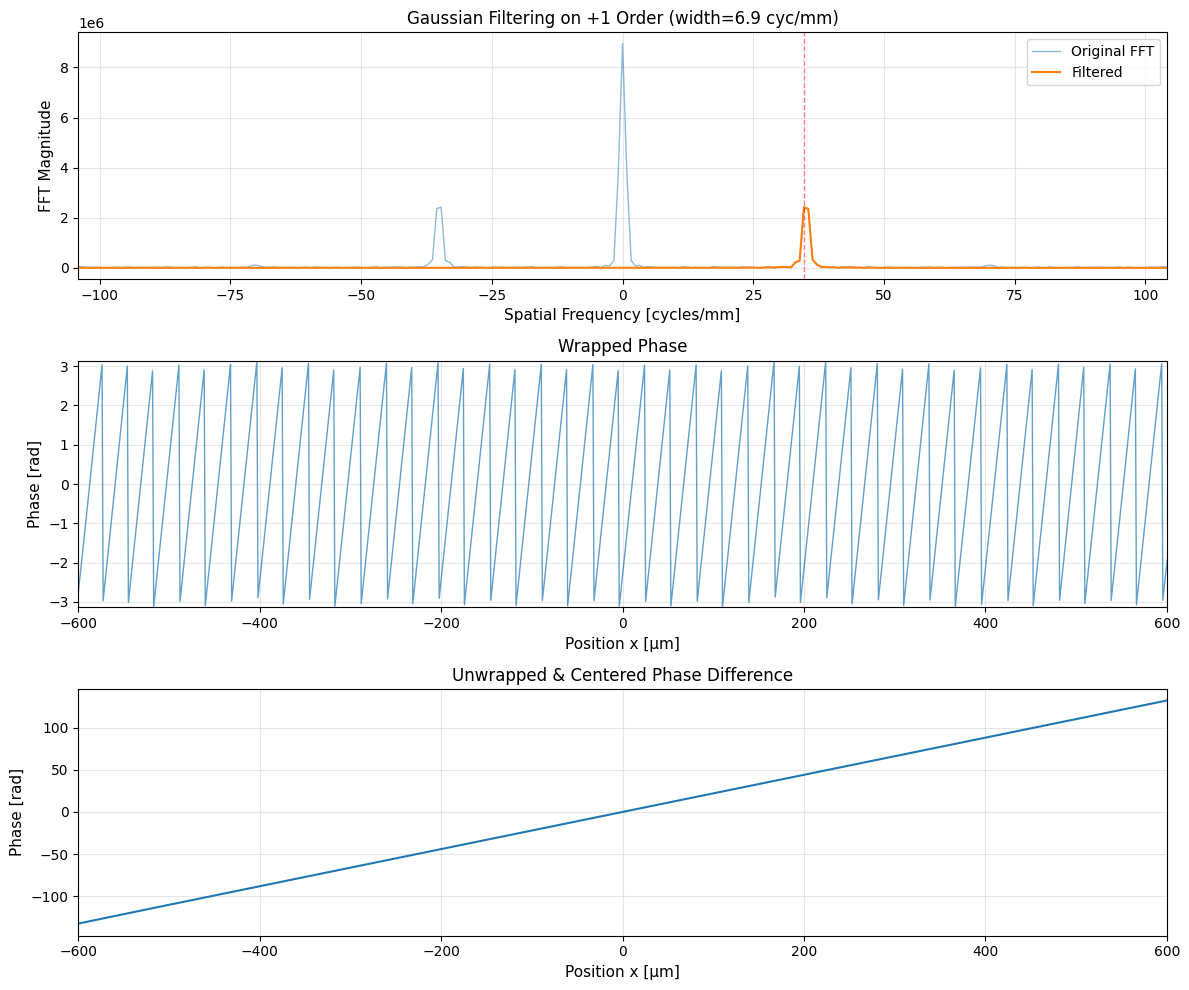

In [31]:
# Gaussian filter centered at carrier
filter_width = k_carrier / 5.0  # Width = 20% of carrier frequency

gaussian_filter = np.exp(-0.5 * ((freq_x - k_carrier) / filter_width)**2)
fft_filtered = fft_result * gaussian_filter

# Inverse FFT to get complex field
E_reconstructed = np.fft.ifftshift(np.fft.ifft(np.fft.ifftshift(fft_filtered)))

# Extract wrapped phase 
phase_wrapped = np.angle(E_reconstructed)

# Unwrap and center
phase_unwrapped = np.unwrap(phase_wrapped)
phase_centered = phase_unwrapped - phase_unwrapped[Nx//2]

print(f"Filter width: {filter_width:.0f} cycles/m ({filter_width*1e-3:.1f} cyc/mm)")

# Visualize filtering and phase
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# FFT with Gaussian filter overlay
ax = axes[0]
ax.plot(freq_x * 1e-3, fft_magnitude, linewidth=1, alpha=0.5, label='Original FFT')
ax.plot(freq_x * 1e-3, np.abs(fft_filtered), linewidth=1.5, label='Filtered')
ax.axvline(k_carrier * 1e-3, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlim(-3*k_carrier * 1e-3, 3*k_carrier * 1e-3)
ax.set_xlabel('Spatial Frequency [cycles/mm]', fontsize=11)
ax.set_ylabel('FFT Magnitude', fontsize=11)
ax.set_title(f'Gaussian Filtering on +1 Order (width={filter_width*1e-3:.1f} cyc/mm)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Wrapped phase
ax = axes[1]
ax.plot(x_m * 1e6, phase_wrapped, linewidth=1, alpha=0.7)
ax.set_xlabel('Position x [μm]', fontsize=11)
ax.set_ylabel('Phase [rad]', fontsize=11)
ax.set_title('Wrapped Phase', fontsize=12)
ax.set_xlim(-600, 600)
ax.set_ylim(-np.pi, np.pi)
ax.grid(True, alpha=0.3)

# Unwrapped and centered phase
ax = axes[2]
ax.plot(x_m * 1e6, phase_centered, linewidth=1.5)
ax.set_xlabel('Position x [μm]', fontsize=11)
ax.set_ylabel('Phase [rad]', fontsize=11)
ax.set_title('Unwrapped & Centered Phase Difference', fontsize=12)
ax.set_xlim(-600, 600)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

__Wavefront Reconstruction__

We reconstruct the wavefront $W(x)$ from the unwrapped phase $\phi_\text{centered}(x)$ using the lateral shearing relation:

$$W(x) = \frac{p}{\lambda z_T} \int \Delta\phi(x)\, dx \quad \text{[rad]}$$

where $p$ is the ideal grating pitch, $\lambda$ the wavelength, and $z_T$ the grating-to-detector distance.

**Carrier removal.**  
After unwrapping, $\phi_\text{centered}$ still contains the bare grating tilt ramp $2\pi x/p$. We subtract it using the *ideal* pitch (not the FFT-measured peak), because the difference between the ideal and measured carrier frequencies encodes the beam's wavefront curvature — subtracting the measured carrier would erase it.

$$\Delta\phi(x) = \phi_\text{centered}(x) - \frac{2\pi}{p}\!\left(x - x_0\right)$$

**Integration.**  
Integrate $\Delta\phi$ and apply the scaling factor $p/(\lambda z_T)$. The leading minus sign follows from the sign convention of `np.angle` combined with the +1-order FFT extraction.

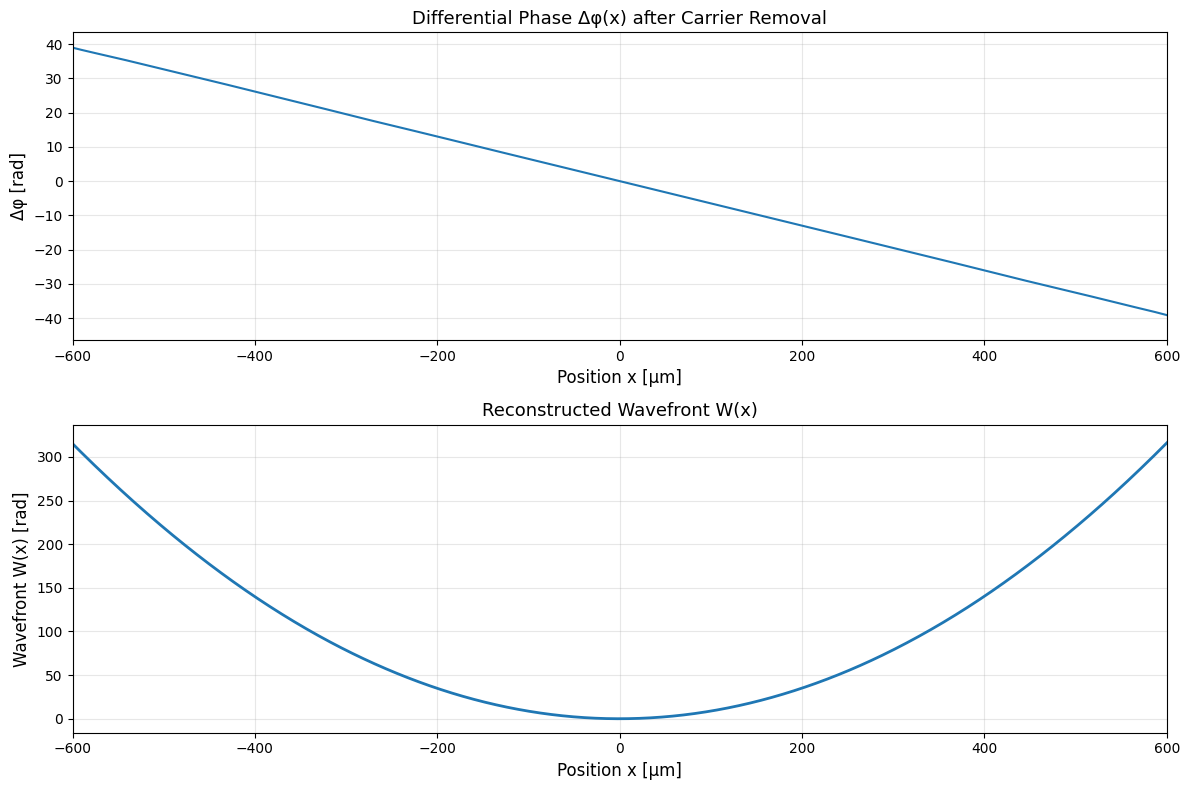

In [32]:
z_T = 0.4  # Grating-to-detector distance [m], fixed by hardware

carrier_ramp = 2 * np.pi / grating_pitch_m * x_m
carrier_ramp_centered = carrier_ramp - carrier_ramp[Nx//2]
delta_phi = phase_centered - carrier_ramp_centered

W_temp = -np.cumsum(delta_phi) * dx_m * grating_pitch_m / wavelength_m / z_T
wavefront_reconstructed = W_temp - W_temp[Nx//2]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ax = axes[0]
ax.plot(x_m * 1e6, delta_phi, linewidth=1.5)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Δφ [rad]', fontsize=12)
ax.set_title('Differential Phase Δφ(x) after Carrier Removal', fontsize=13)
ax.set_xlim(-600, 600)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_m * 1e6, wavefront_reconstructed, linewidth=2)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Wavefront W(x) [rad]', fontsize=12)
ax.set_title('Reconstructed Wavefront W(x)', fontsize=13)
ax.set_xlim(-600, 600)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Detrending

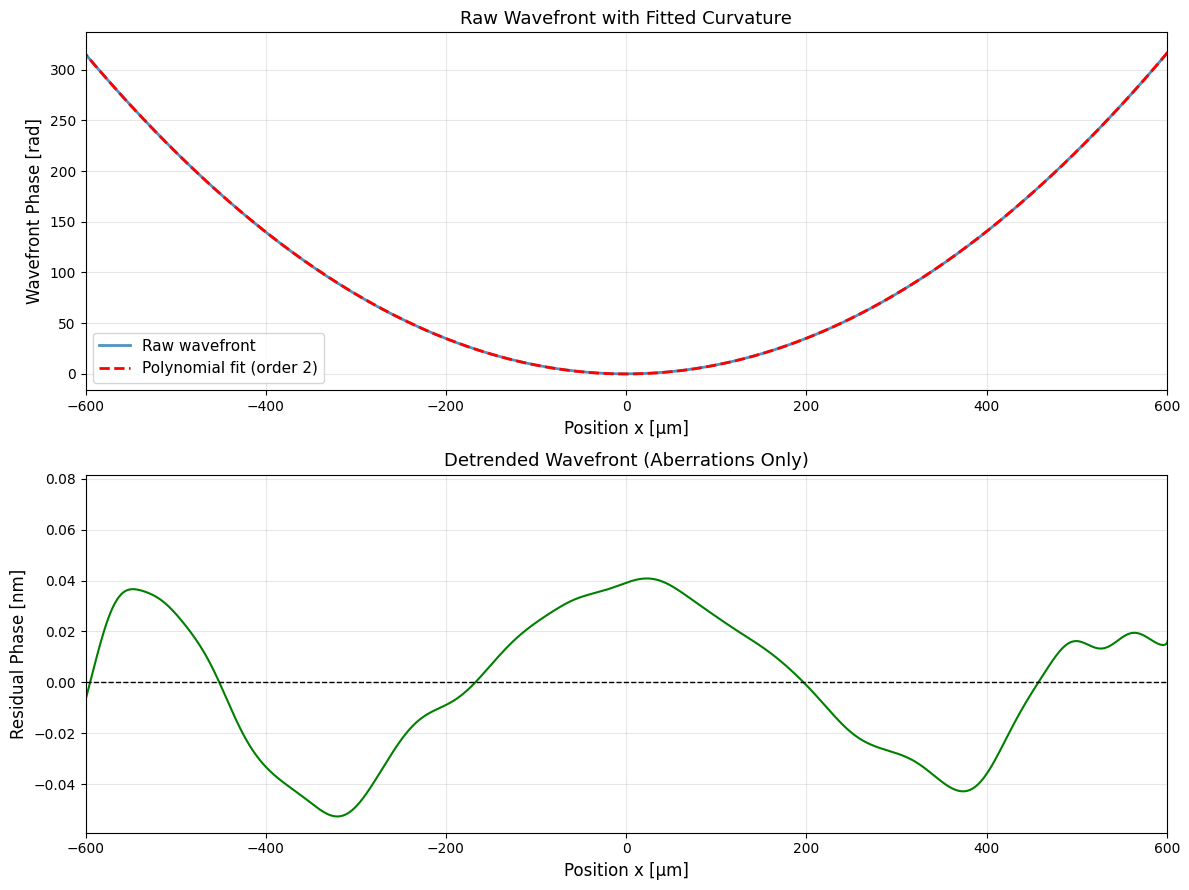

Aberration metrics
------------------------------------------------------------
RMS Wavefront Error: 0.086 rad = 0.014 waves = 0.028 nm
Peak-to-Valley:      0.288 rad = 0.046 waves = 0.094 nm


In [35]:
# Fit 2nd order polynomial (removes defocus curvature)
poly_order = 2
poly_coeffs = np.polyfit(x_m, wavefront_reconstructed, deg=poly_order)
wavefront_fitted = np.polyval(poly_coeffs, x_m)

# Subtract fit to get detrended wavefront (aberrations only)
wavefront_detrended = wavefront_reconstructed - wavefront_fitted
wavefront_detrended_nm = wavefront_detrended * wavelength_m * 1e9 / (2 * np.pi)

# Aberration metrics
wavefront_detrended_calc = wavefront_detrended[center_mask]

rms_rad = np.sqrt(np.mean(wavefront_detrended_calc**2))
rms_waves = rms_rad / (2 * np.pi)
rms_nm = rms_rad * wavelength_m * 1e9 / (2 * np.pi)

pv_rad = np.max(wavefront_detrended_calc) - np.min(wavefront_detrended_calc)
pv_waves = pv_rad / (2 * np.pi)
pv_nm = pv_rad * wavelength_m * 1e9 / (2 * np.pi)

# Visualize raw, fitted, and detrended
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Top: Raw wavefront with polynomial fit
ax = axes[0]
ax.plot(x_m * 1e6, wavefront_reconstructed, linewidth=2, label='Raw wavefront', alpha=0.8)
ax.plot(x_m * 1e6, wavefront_fitted, 'r--', linewidth=2, label=f'Polynomial fit (order {poly_order})')
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Wavefront Phase [rad]', fontsize=12)
ax.set_title('Raw Wavefront with Fitted Curvature', fontsize=13)
ax.set_xlim(-600, 600)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Bottom: Detrended wavefront (aberrations only)
ax = axes[1]
ax.plot(x_m * 1e6, wavefront_detrended_nm, linewidth=1.5, color='green')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Residual Phase [nm]', fontsize=12)
ax.set_title('Detrended Wavefront (Aberrations Only)', fontsize=13)
ax.set_xlim(-600, 600)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"Aberration metrics")
print(f"{'-'*60}")
print(f"RMS Wavefront Error: {rms_rad:.3f} rad = {rms_waves:.3f} waves = {rms_nm:.3f} nm")
print(f"Peak-to-Valley:      {pv_rad:.3f} rad = {pv_waves:.3f} waves = {pv_nm:.3f} nm")
